# MOSAIC Demonstration: 3D Displacement Analysis in CaTiO3 (Small 8x8x8)

This notebook is the small companion to the full 3D CaTiO3 displacement notebook. It uses the checked-in small structure [Catio3_small.rmc6f](config_3D/displacement/Catio3_small.rmc6f) and a matching small average structure so the workflow stays physically meaningful.

The setup is twice smaller in each lattice direction than the full `16x16x16` case:
- structure: `8x8x8`
- selected oxygen sites only
- real-space visualisation and linearity checks adjusted to the small configuration size

This notebook keeps the same reciprocal-space partition into `all`, `sphere`, `rod`, and `rest`, but the main focus is the **real-space displacement field** and its comparison against ground truth.


In [1]:
import os
import sys
import json
import csv
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

MOSAIC_ROOT = Path(os.path.abspath('')).parent
if str(MOSAIC_ROOT) not in sys.path:
    sys.path.insert(0, str(MOSAIC_ROOT))

from core.config.factories.configuration_factory import RMC6fProcessorFactory

EXAMPLE_DIR = Path('config_3D/displacement')
STRUCTURE_FILE = 'Catio3_small.rmc6f'
AVERAGE_FILE = 'Catio3_small_average.rmc6f'
RUN_FILES = {
    'all': EXAMPLE_DIR / 'run_parameters_small_all.json',
    'sphere': EXAMPLE_DIR / 'run_parameters_small_sphere.json',
    'rod': EXAMPLE_DIR / 'run_parameters_small_rod.json',
    'rest': EXAMPLE_DIR / 'run_parameters_small_rest.json',
}

print(f'MOSAIC root   : {MOSAIC_ROOT}')
print(f'Example dir   : {EXAMPLE_DIR}')
print(f'Structure     : {STRUCTURE_FILE}')
print(f'Average file  : {AVERAGE_FILE}')
for tag, path in RUN_FILES.items():
    print(f'Run file [{tag:6s}] : {path}')


MOSAIC root   : /home/f3e/MOSAIC
Example dir   : config_3D/displacement
Structure     : Catio3_small.rmc6f
Average file  : Catio3_small_average.rmc6f
Run file [all   ] : config_3D/displacement/run_parameters_small_all.json
Run file [sphere] : config_3D/displacement/run_parameters_small_sphere.json
Run file [rod   ] : config_3D/displacement/run_parameters_small_rod.json
Run file [rest  ] : config_3D/displacement/run_parameters_small_rest.json


## 1. Inspect the Small Structure and JSON Configuration

The small case uses the same four reciprocal-space masks as the full notebook, but the real-space cell box is reduced to `0..7` in each direction and the outputs are written to dedicated `output_disp_small_*` folders.


In [2]:
def load_run_bundle(run_path: Path):
    run_payload = json.loads(run_path.read_text(encoding='utf-8'))
    input_path = (run_path.parent / run_payload['input_parameters_path']).resolve()
    input_payload = json.loads(input_path.read_text(encoding='utf-8'))
    return run_payload, input_path, input_payload

bundles = {tag: load_run_bundle(path) for tag, path in RUN_FILES.items()}

processor = RMC6fProcessorFactory().create_processor(
    str((EXAMPLE_DIR / STRUCTURE_FILE).resolve()),
    processor_type='read',
    average_file_path=str((EXAMPLE_DIR / AVERAGE_FILE).resolve()),
)
processor.process()

vectors = processor.get_vectors()
actual = processor.get_coordinates().copy()
average = processor.get_average_coordinates().copy()
cell_ids = processor.get_cell_ids().copy()
elements = processor.get_elements().copy()
refnumbers = processor.get_refnumbers().copy()

df = pd.DataFrame({
    'element': elements.to_numpy(),
    'refnumber': refnumbers.to_numpy(),
    'x': actual['x'].to_numpy(),
    'y': actual['y'].to_numpy(),
    'z': actual['z'].to_numpy(),
    'xav': average['x'].to_numpy(),
    'yav': average['y'].to_numpy(),
    'zav': average['z'].to_numpy(),
    'cell_x': cell_ids['x'].to_numpy(),
    'cell_y': cell_ids['y'].to_numpy(),
    'cell_z': cell_ids['z'].to_numpy(),
})

mask_points = (df['element'] == 'O') & (df['refnumber'].isin([2, 3, 4]))
selected = df.loc[mask_points].copy()
lengths = np.array([np.linalg.norm(vectors[i, :]) for i in range(3)])
selected['ux_true'] = selected['x'] - selected['xav']
selected['uy_true'] = selected['y'] - selected['yav']
selected['uz_true'] = selected['z'] - selected['zav']
selected['ux_true'] -= np.round(selected['ux_true'] / lengths[0]) * lengths[0]
selected['uy_true'] -= np.round(selected['uy_true'] / lengths[1]) * lengths[1]
selected['uz_true'] -= np.round(selected['uz_true'] / lengths[2]) * lengths[2]
selected['u_true_mag'] = np.sqrt(selected['ux_true']**2 + selected['uy_true']**2 + selected['uz_true']**2)

print('Cell lengths (A):', lengths)
print('Total atoms      :', len(df))
print('Selected O sites :', len(selected))
print(selected.groupby('refnumber').size())
print() 
print('JSON outputs:')
for tag, (_, input_path, payload) in bundles.items():
    print(f'[{tag}] input  : {input_path.name}')
    print(f'[{tag}] output : {payload["paths"]["output_directory"]}')
    print(f'[{tag}] mask   : {payload["reciprocal_space"]["mask"]["equation"]}')
    print()


Cell lengths (A): [29.8988 29.8988 30.36  ]
Total atoms      : 2560
Selected O sites : 1536
refnumber
2    512
3    512
4    512
dtype: int64

JSON outputs:
[all] input  : input_parameters_small_all.json
[all] output : ./output_disp_small_all
[all] mask   : (((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2 + (Mod(l,1.0) - 0.5)**2) >= 0)

[sphere] input  : input_parameters_small_sphere.json
[sphere] output : ./output_disp_small_sphere
[sphere] mask   : (((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2 + (Mod(l,1.0) - 0.5)**2) < (0.2501)**2)

[rod] input  : input_parameters_small_rod.json
[rod] output : ./output_disp_small_rod
[rod] mask   : (((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2) <= (0.1876)**2) & (((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2 + (Mod(l,1.0) - 0.5)**2) >= (0.2501)**2)

[rest] input  : input_parameters_small_rest.json
[rest] output : ./output_disp_small_rest
[rest] mask   : (((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2) > (0.1876)**2) & (((Mod(h,1.0) - 0.5)**2 + (

## 2. Run the Small MOSAIC Cases

These cells call the checked-in small `run_parameters_small_*.json` files in fresh subprocesses.


In [3]:
def run_mosaic(tag: str):
    run_path = RUN_FILES[tag].resolve()
    print('=' * 72)
    print(f'Running MOSAIC -- {tag.upper()} (small)')
    print('=' * 72)
    subprocess.run(
        [sys.executable, '-m', 'core.main', str(run_path)],
        cwd=str(MOSAIC_ROOT),
        env=os.environ.copy(),
        check=True,
    )


### Run 1/4: All


In [4]:
run_mosaic('all')


Running MOSAIC -- ALL (small)
2026-07-07 11:14:37,897 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-07-07 11:14:37,897 - [INFO] - app - (main.py:84) - Using input parameters: config_3D/displacement/input_parameters_small_all.json
2026-07-07 11:14:37,897 - [INFO] - app - (main.py:85) - Resolved configuration root: examples/config_3D/displacement
2026-07-07 11:14:37,897 - [INFO] - app - (main.py:86) - Runtime settings: backend=local max_workers=2 threads_per_worker=8 processes=False
2026-07-07 11:14:38,035 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-07-07 11:14:38,035 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-07-07 11:14:38,036 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 2560 points, dropped 0 outsi

Residual-field:  50%|█████     | 3/6 [00:05<00:05,  1.69s/batch, done=chunk0/p2:1-320 (n=320) | running=3 | elapsed=5s | eta=5s | rate=0.6/s] 

2026-07-07 11:15:00,203 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [####################] 6/6 (100%) | running=4 | chunk=1 | intervals=1-320 (n=320)


Residual-field: 100%|██████████| 6/6 [00:07<00:00,  1.31s/batch, done=chunk1/p2:1-320 (n=320) | running=0 | elapsed=8s]                      


2026-07-07 11:15:03,093 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 0) | writes=1 | bytes=94845774 | wall=0.000s
2026-07-07 11:15:03,094 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 1) | writes=1 | bytes=94845774 | wall=0.000s
2026-07-07 11:15:03,094 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 2) | writes=1 | bytes=94845774 | wall=0.000s
2026-07-07 11:15:03,094 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(1, 0) | writes=1 | bytes=94845774 | wall=0.000s
2026-07-07 11:15:03,094 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Re

### Run 2/4: Sphere


In [5]:
run_mosaic('sphere')


Running MOSAIC -- SPHERE (small)
2026-07-07 11:15:13,336 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-07-07 11:15:13,337 - [INFO] - app - (main.py:84) - Using input parameters: config_3D/displacement/input_parameters_small_sphere.json
2026-07-07 11:15:13,337 - [INFO] - app - (main.py:85) - Resolved configuration root: examples/config_3D/displacement
2026-07-07 11:15:13,337 - [INFO] - app - (main.py:86) - Runtime settings: backend=local max_workers=2 threads_per_worker=8 processes=False
2026-07-07 11:15:13,430 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-07-07 11:15:13,430 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-07-07 11:15:13,431 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 2560 points, dropped 0

Residual-field:  50%|█████     | 3/6 [00:02<00:02,  1.11batch/s, done=chunk0/p2:1-256 (n=256) | running=3 | elapsed=3s | eta=3s | rate=1.1/s]

2026-07-07 11:15:28,833 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [####################] 6/6 (100%) | running=4 | chunk=1 | intervals=1-256 (n=256)


Residual-field: 100%|██████████| 6/6 [00:04<00:00,  1.35batch/s, done=chunk1/p2:1-256 (n=256) | running=0 | elapsed=4s]                      


2026-07-07 11:15:30,653 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 0) | writes=1 | bytes=94845262 | wall=0.000s
2026-07-07 11:15:30,653 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 1) | writes=1 | bytes=94845262 | wall=0.000s
2026-07-07 11:15:30,653 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 2) | writes=1 | bytes=94845262 | wall=0.000s
2026-07-07 11:15:30,653 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(1, 0) | writes=1 | bytes=94845262 | wall=0.000s
2026-07-07 11:15:30,653 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Re

### Run 3/4: Rod \ Sphere


In [6]:
run_mosaic('rod')


Running MOSAIC -- ROD (small)
2026-07-07 11:15:40,470 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-07-07 11:15:40,470 - [INFO] - app - (main.py:84) - Using input parameters: config_3D/displacement/input_parameters_small_rod.json
2026-07-07 11:15:40,470 - [INFO] - app - (main.py:85) - Resolved configuration root: examples/config_3D/displacement
2026-07-07 11:15:40,470 - [INFO] - app - (main.py:86) - Runtime settings: backend=local max_workers=2 threads_per_worker=8 processes=False
2026-07-07 11:15:40,574 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-07-07 11:15:40,574 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-07-07 11:15:40,575 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 2560 points, dropped 0 outsi

Residual-field:  33%|███▎      | 2/6 [00:03<00:06,  1.72s/batch, done=chunk0/p1:1-320 (n=320) | running=3 | elapsed=3s | eta=7s | rate=0.6/s] 

2026-07-07 11:15:59,524 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [####################] 6/6 (100%) | running=4 | chunk=1 | intervals=1-320 (n=320)


Residual-field: 100%|██████████| 6/6 [00:06<00:00,  1.01s/batch, done=chunk1/p2:1-320 (n=320) | running=0 | elapsed=6s]                      


2026-07-07 11:16:02,176 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 0) | writes=1 | bytes=94845774 | wall=0.000s
2026-07-07 11:16:02,176 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 1) | writes=1 | bytes=94845774 | wall=0.000s
2026-07-07 11:16:02,176 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 2) | writes=1 | bytes=94845774 | wall=0.000s
2026-07-07 11:16:02,176 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(1, 0) | writes=1 | bytes=94845774 | wall=0.000s
2026-07-07 11:16:02,176 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Re

### Run 4/4: Rest


In [7]:
run_mosaic('rest')


Running MOSAIC -- REST (small)
2026-07-07 11:16:12,834 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-07-07 11:16:12,834 - [INFO] - app - (main.py:84) - Using input parameters: config_3D/displacement/input_parameters_small_rest.json
2026-07-07 11:16:12,834 - [INFO] - app - (main.py:85) - Resolved configuration root: examples/config_3D/displacement
2026-07-07 11:16:12,834 - [INFO] - app - (main.py:86) - Runtime settings: backend=local max_workers=2 threads_per_worker=8 processes=False
2026-07-07 11:16:12,935 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-07-07 11:16:12,935 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-07-07 11:16:12,937 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 2560 points, dropped 0 out

Residual-field:  50%|█████     | 3/6 [00:05<00:05,  1.72s/batch, done=chunk1/p0:1-320 (n=320) | running=3 | elapsed=5s | eta=5s | rate=0.6/s] 

2026-07-07 11:16:37,409 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:118) - Residual-field queue [####################] 6/6 (100%) | running=4 | chunk=1 | intervals=1-320 (n=320)


Residual-field: 100%|██████████| 6/6 [00:07<00:00,  1.31s/batch, done=chunk1/p1:1-320 (n=320) | running=0 | elapsed=8s]                      


2026-07-07 11:16:40,193 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 0) | writes=1 | bytes=94845774 | wall=0.000s
2026-07-07 11:16:40,193 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 1) | writes=1 | bytes=94845774 | wall=0.000s
2026-07-07 11:16:40,193 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, 2) | writes=1 | bytes=94845774 | wall=0.000s
2026-07-07 11:16:40,193 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Residual-field finalize checkpoints | backend=local_restartable | target=(1, 0) | writes=1 | bytes=94845774 | wall=0.000s
2026-07-07 11:16:40,193 - [INFO] - core.residual_field.progress_logging - (progress_logging.py:306) - Re

## 3. Load the Small Decoded Displacements

All chunks are concatenated and aligned by `central_point_id`, exactly as in the full notebook.


In [8]:
def load_displacements(output_dir: Path):
    proc_dir = output_dir / 'processed_point_data'
    csv_paths = sorted(proc_dir.glob('chunk_*_site_displacements.csv'))
    if not csv_paths:
        csv_paths = sorted(proc_dir.glob('output_chunk_*_first_moment_displacements.csv'))
    if not csv_paths:
        raise FileNotFoundError(f'No displacement CSV files found in {proc_dir}')
    frames = [pd.read_csv(csv_path, sep='	') for csv_path in csv_paths]
    return pd.concat(frames, ignore_index=True).sort_values('central_point_id').reset_index(drop=True)

output_dirs = {tag: EXAMPLE_DIR / Path(bundle[2]['paths']['output_directory']) for tag, bundle in bundles.items()}
results = {tag: load_displacements(out) for tag, out in output_dirs.items()}
for tag, frame in results.items():
    print(tag, len(frame), 'sites loaded')

selected_sorted = selected.sort_index().copy()
for tag, frame in results.items():
    if not np.array_equal(frame['central_point_id'].to_numpy(), selected_sorted.index.to_numpy()):
        raise ValueError(f'central_point_id mismatch for {tag}')
    selected_sorted[f'ux_{tag}'] = frame['ux'].to_numpy()
    selected_sorted[f'uy_{tag}'] = frame['uy'].to_numpy()
    selected_sorted[f'uz_{tag}'] = frame['uz'].to_numpy()
    selected_sorted[f'u_{tag}_mag'] = np.sqrt(frame['ux'].to_numpy()**2 + frame['uy'].to_numpy()**2 + frame['uz'].to_numpy()**2)

print() 
print('RMS displacement magnitudes:')
for tag in ['all', 'sphere', 'rod', 'rest']:
    print(f'  {tag:6s}: {np.sqrt(np.mean(selected_sorted[f"u_{tag}_mag"]**2)):.4f} A')
print(f'  true  : {np.sqrt(np.mean(selected_sorted["u_true_mag"]**2)):.4f} A')


all 1536 sites loaded
sphere 1536 sites loaded
rod 1536 sites loaded
rest 1536 sites loaded

RMS displacement magnitudes:
  all   : 0.2250 A
  sphere: 0.1840 A
  rod   : 0.0660 A
  rest  : 0.1114 A
  true  : 0.2253 A


## 4. Real-Space Only: Mid-Plane Displacement Maps

This small notebook focuses on the real-space view. We plot the mid-plane of one oxygen sublattice so the effect of the reciprocal-space partition is easy to compare across `all`, `sphere`, `rod`, and `rest`.


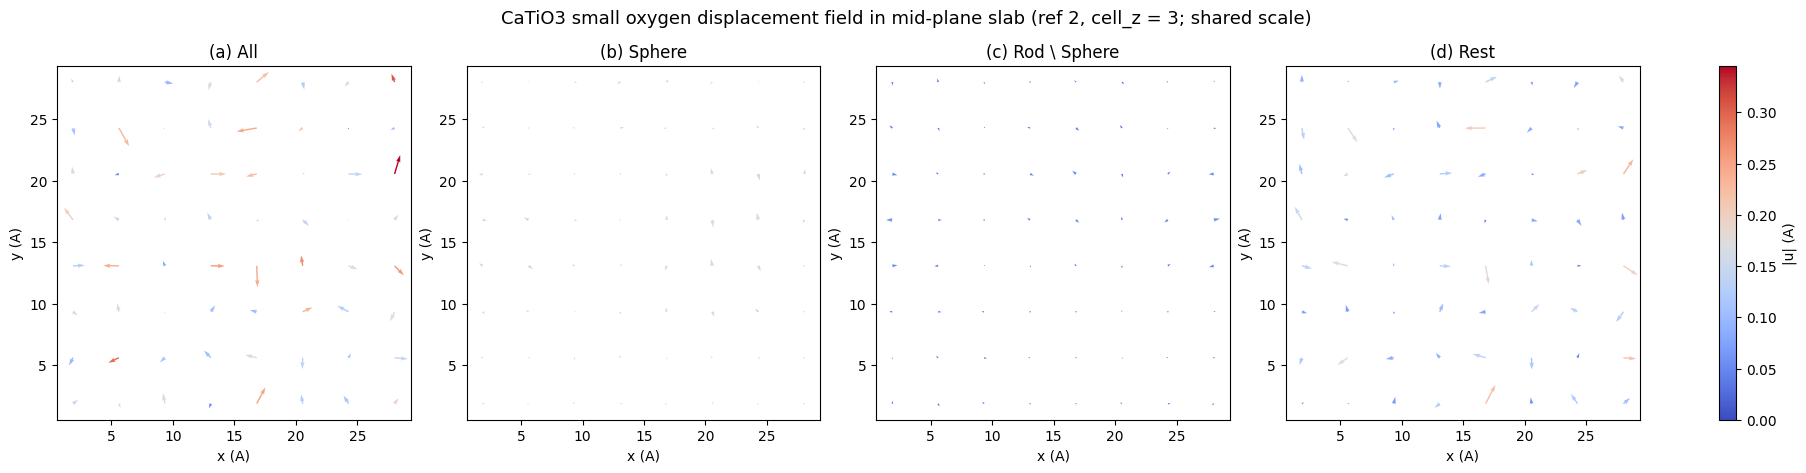

In [9]:
plot_ref = 2
plot_z = int(np.median(selected_sorted['cell_z']))
slab = selected_sorted[(selected_sorted['refnumber'] == plot_ref) & (selected_sorted['cell_z'] == plot_z)].copy()
slab = slab.sort_values(['cell_y', 'cell_x']).reset_index(drop=True)

datasets = [
    ('all', '(a) All'),
    ('sphere', '(b) Sphere'),
    ('rod', '(c) Rod \ Sphere'),
    ('rest', '(d) Rest'),
]

# Shared colour and vector scale for all panels.
all_mags = np.concatenate([slab[f'u_{tag}_mag'].to_numpy() for tag, _ in datasets])
color_norm = Normalize(vmin=0.0, vmax=float(np.nanmax(all_mags)))
vector_scale = 0.12

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), constrained_layout=True)
q = None
for ax, (tag, title) in zip(axes, datasets):
    mag = slab[f'u_{tag}_mag'].to_numpy()
    q = ax.quiver(
        slab['xav'].to_numpy(),
        slab['yav'].to_numpy(),
        slab[f'ux_{tag}'].to_numpy(),
        slab[f'uy_{tag}'].to_numpy(),
        mag,
        cmap='coolwarm',
        norm=color_norm,
        angles='xy',
        scale_units='xy',
        scale=vector_scale,
        width=0.004,
    )
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('x (A)')
    ax.set_ylabel('y (A)')

fig.colorbar(q, ax=axes, shrink=0.82, label='|u| (A)')
fig.suptitle(f'CaTiO3 small oxygen displacement field in mid-plane slab (ref {plot_ref}, cell_z = {plot_z}; shared scale)', fontsize=13, y=1.03)
plt.show()



## 5. Ground-Truth Comparison and Linearity Check

As in the full notebook, we compare the unfiltered small reconstruction to the true displacements and verify the additive decomposition `sphere + rod + rest ≈ all`.


Linearity check: sphere + rod + rest = all
  RMS |u_all|      : 0.225005 A
  RMS residual     : 5.33e-08 A
  Relative error   : 2.37e-07

Ground truth check: u_all vs u_true
  RMS |u_true|     : 0.225277 A
  RMS residual     : 6.24e-03 A
  Relative error   : 2.77e-02

Ground truth check (per-component -- the parity metric):
  Component Pearson r        : 0.9996
  Best-fit slope (all/true)  : 0.9984
  Mean direction cosine      : 0.9997
  Flipped sites (cos < 0)    : 0.00%


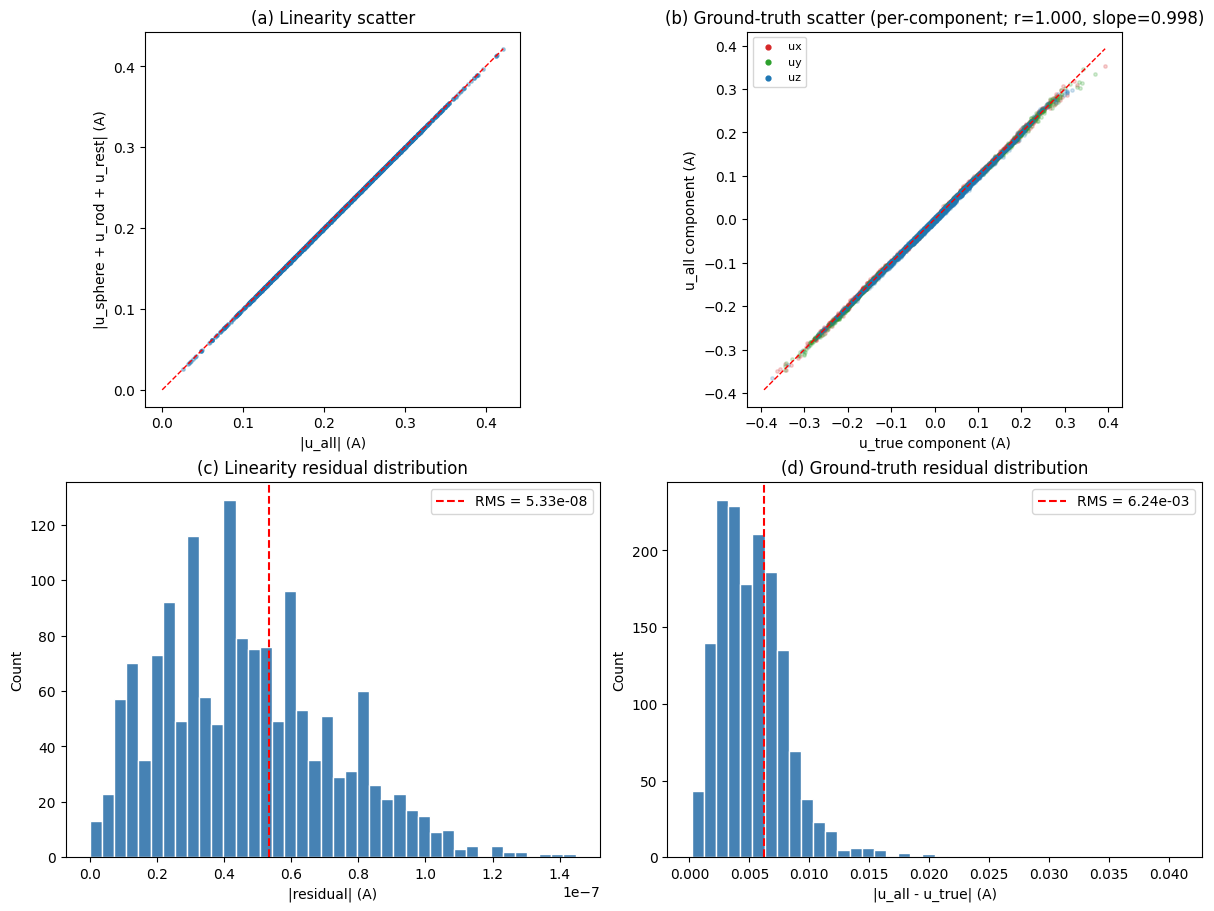

In [10]:
ux_true = selected_sorted['ux_true'].to_numpy()
uy_true = selected_sorted['uy_true'].to_numpy()
uz_true = selected_sorted['uz_true'].to_numpy()

ux_all = selected_sorted['ux_all'].to_numpy()
uy_all = selected_sorted['uy_all'].to_numpy()
uz_all = selected_sorted['uz_all'].to_numpy()

ux_sum = selected_sorted['ux_sphere'].to_numpy() + selected_sorted['ux_rod'].to_numpy() + selected_sorted['ux_rest'].to_numpy()
uy_sum = selected_sorted['uy_sphere'].to_numpy() + selected_sorted['uy_rod'].to_numpy() + selected_sorted['uy_rest'].to_numpy()
uz_sum = selected_sorted['uz_sphere'].to_numpy() + selected_sorted['uz_rod'].to_numpy() + selected_sorted['uz_rest'].to_numpy()

resid_lin = np.sqrt((ux_sum - ux_all)**2 + (uy_sum - uy_all)**2 + (uz_sum - uz_all)**2)
resid_gt = np.sqrt((ux_all - ux_true)**2 + (uy_all - uy_true)**2 + (uz_all - uz_true)**2)
full_mag = selected_sorted['u_all_mag'].to_numpy()
true_mag = selected_sorted['u_true_mag'].to_numpy()
sum_mag = np.sqrt(ux_sum**2 + uy_sum**2 + uz_sum**2)

rms_lin = np.sqrt(np.mean(resid_lin**2))
rms_gt = np.sqrt(np.mean(resid_gt**2))
rms_full = np.sqrt(np.mean(full_mag**2))
rms_true = np.sqrt(np.mean(true_mag**2))

# Signed per-component arrays. Validate the vector reconstruction on the
# components, NOT on |u|: the magnitude is a positive-definite (folded) quantity,
# so per-site reconstruction noise turns into an upward-biased fan in a
# |u_all| vs |u_true| scatter even when the underlying vectors sit on the line.
# The component scatter (panel b) is the honest parity plot.
comp_true = np.concatenate([ux_true, uy_true, uz_true])
comp_all = np.concatenate([ux_all, uy_all, uz_all])
comp_r = np.corrcoef(comp_true, comp_all)[0, 1]
comp_slope = np.sum(comp_true * comp_all) / np.sum(comp_true**2)
cos_align = np.sum(np.stack([ux_all, uy_all, uz_all]) * np.stack([ux_true, uy_true, uz_true]), axis=0) / (
    np.maximum(full_mag * true_mag, 1e-30))

print('Linearity check: sphere + rod + rest = all')
print(f'  RMS |u_all|      : {rms_full:.6f} A')
print(f'  RMS residual     : {rms_lin:.2e} A')
print(f'  Relative error   : {rms_lin / rms_full:.2e}')
print()
print('Ground truth check: u_all vs u_true')
print(f'  RMS |u_true|     : {rms_true:.6f} A')
print(f'  RMS residual     : {rms_gt:.2e} A')
print(f'  Relative error   : {rms_gt / rms_true:.2e}')
print()
print('Ground truth check (per-component -- the parity metric):')
print(f'  Component Pearson r        : {comp_r:.4f}')
print(f'  Best-fit slope (all/true)  : {comp_slope:.4f}')
print(f'  Mean direction cosine      : {cos_align.mean():.4f}')
print(f'  Flipped sites (cos < 0)    : {np.mean(cos_align < 0):.2%}')

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

ax = axes[0, 0]
ax.plot([0, max(full_mag.max(), sum_mag.max())], [0, max(full_mag.max(), sum_mag.max())], 'r--', lw=1)
ax.scatter(full_mag, sum_mag, s=6, alpha=0.35)
ax.set_xlabel('|u_all| (A)')
ax.set_ylabel('|u_sphere + u_rod + u_rest| (A)')
ax.set_title('(a) Linearity scatter')
ax.set_aspect('equal')

ax = axes[1, 0]
ax.hist(resid_lin, bins=40, color='steelblue', edgecolor='white')
ax.axvline(rms_lin, color='red', ls='--', label=f'RMS = {rms_lin:.2e}')
ax.set_xlabel('|residual| (A)')
ax.set_ylabel('Count')
ax.set_title('(c) Linearity residual distribution')
ax.legend()

# (b) Per-component parity: stack ux, uy, uz of decoded vs true. This collapses
# onto y = x when the reconstruction is good, unlike the magnitude scatter which
# folds direction agreement away and fans out near the origin by construction.
ax = axes[0, 1]
comp_lim = float(np.max(np.abs(np.concatenate([comp_true, comp_all]))))
ax.plot([-comp_lim, comp_lim], [-comp_lim, comp_lim], 'r--', lw=1)
for comp_t, comp_a, comp_c in (
    (ux_true, ux_all, 'tab:red'),
    (uy_true, uy_all, 'tab:green'),
    (uz_true, uz_all, 'tab:blue'),
):
    ax.scatter(comp_t, comp_a, s=6, alpha=0.2, color=comp_c)
ax.scatter([], [], s=12, color='tab:red', label='ux')
ax.scatter([], [], s=12, color='tab:green', label='uy')
ax.scatter([], [], s=12, color='tab:blue', label='uz')
ax.set_xlabel('u_true component (A)')
ax.set_ylabel('u_all component (A)')
ax.set_title(f'(b) Ground-truth scatter (per-component; r={comp_r:.3f}, slope={comp_slope:.3f})')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)

ax = axes[1, 1]
ax.hist(resid_gt, bins=40, color='steelblue', edgecolor='white')
ax.axvline(rms_gt, color='red', ls='--', label=f'RMS = {rms_gt:.2e}')
ax.set_xlabel('|u_all - u_true| (A)')
ax.set_ylabel('Count')
ax.set_title('(d) Ground-truth residual distribution')
ax.legend()

plt.show()


### Reading panel (b)

Panel (b) compares the *signed* displacement components against the ground truth. Component-wise comparison is used because a magnitude-vs-magnitude scatter is biased upward for small displacements; the signed components sit symmetrically on the y = x line when the reconstruction is good. The configured real-space patch step satisfies the sampling requirement for this `hkl` range.


## 6. Summary

This small CaTiO3 notebook keeps the same physical decomposition as the full 3D case but scales the real-space problem down to an `8x8x8` supercell.

Compared with the full notebook, the emphasis here is on the **real-space displacement field**:
- smaller structure and smaller selected oxygen set
- same `all` / `sphere` / `rod` / `rest` reciprocal-space partition
- same ground-truth and linearity checks
- simpler real-space visualisation focused on the mid-plane slab


In [11]:
# --- Cleanup (optional) ---
# Uncomment to remove generated small output directories after inspection.
# for tag, bundle in bundles.items():
#     out = EXAMPLE_DIR / Path(bundle[2]['paths']['output_directory'])
#     if out.exists():
#         shutil.rmtree(out)
#         print(f'Removed {out}')
